# Mistral AI Scoring - Progress Monitoring & Analysis

This notebook helps you:
1. **Monitor scoring progress** in real-time
2. **Check data quality** as scoring proceeds
3. **Analyze results** incrementally
4. **Visualize distributions** and relationships

## Current Scoring Status

- **Script**: `./scripts/run_scoring_mistral.sh`
- **Input**: 144,439 conversations
- **Output**: `data/scores/wildchat_full_scored_mistral.csv`
- **Checkpoints**: Every 1,000 conversations
- **Expected time**: ~50 hours with conservative delays

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")
print(f"Current time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
Current time: 2025-11-05 18:43:32


## 1. Check Scoring Progress

First, let's see how many conversations have been scored so far.

In [2]:
# File paths
SCORED_FILE = '../data/scores/wildchat_full_scored_mistral.csv'
ORIGINAL_FILE = '../data/filtered/wildchat_full_preprocessed.csv'

# Total expected (for sampling approach)
TOTAL_CONVERSATIONS = 144439
TARGET_SAMPLE = 15000  # Target for valid statistical analysis

# Check if scored file exists
if os.path.exists(SCORED_FILE):
    # Get file size
    file_size_mb = os.path.getsize(SCORED_FILE) / (1024 * 1024)
    
    print("Loading file to count scored conversations...")
    # Use pandas to properly count rows (handles CSV with newlines in data)
    df_temp = pd.read_csv(SCORED_FILE)
    total_rows = len(df_temp)
    
    # Count how many actually have scores
    scored_count = df_temp['empathy_score'].notna().sum()
    
    # Calculate progress toward target
    progress_pct = (scored_count / TARGET_SAMPLE) * 100
    remaining_to_target = max(0, TARGET_SAMPLE - scored_count)
    
    print("\n" + "="*70)
    print("📊 SCORING PROGRESS - SAMPLING APPROACH")
    print("="*70)
    print(f"✓ File exists: {SCORED_FILE}")
    print(f"  File size: {file_size_mb:.2f} MB")
    print(f"  Total rows in file: {total_rows:,}")
    print(f"\n📈 Progress toward target ({TARGET_SAMPLE:,} conversations):")
    print(f"  Scored:     {scored_count:,} conversations")
    print(f"  Remaining:  {remaining_to_target:,} to reach target")
    print(f"  Progress:   {min(progress_pct, 100):.1f}%")
    
    if scored_count >= TARGET_SAMPLE:
        print(f"\n🎉 TARGET REACHED! You can stop the script.")
        print(f"   Sample size: {scored_count:,} (sufficient for analysis)")
    else:
        print(f"\n⏱️  Estimated time to target (at 0.33 conv/s):")
        print(f"  {remaining_to_target/(0.33*3600):.1f} hours")
    
    print("="*70)
    
else:
    print("❌ Scored file not found yet!")
    print(f"   Looking for: {SCORED_FILE}")
    print("\n💡 The file will be created after the first checkpoint (1000 conversations)")
    print("   Run: ./scripts/run_scoring_mistral.sh")

Loading file to count scored conversations...

📊 SCORING PROGRESS - SAMPLING APPROACH
✓ File exists: ../data/scores/wildchat_full_scored_mistral.csv
  File size: 202.90 MB
  Total rows in file: 144,439

📈 Progress toward target (15,000 conversations):
  Scored:     8,989 conversations
  Remaining:  6,011 to reach target
  Progress:   59.9%

⏱️  Estimated time to target (at 0.33 conv/s):
  5.1 hours


## 1.2 Create Clean Sample Dataset

Extract only the conversations with both scores completed and save to a new file.

In [3]:
# Create clean sample dataset with only fully scored conversations
if os.path.exists(SCORED_FILE):
    print("Loading scored file...")
    df_full = pd.read_csv(SCORED_FILE)
    
    print(f"Total rows in file: {len(df_full):,}")
    
    # Filter to keep only rows with BOTH scores present
    df_clean = df_full.dropna(subset=['empathy_score', 'attachment_score'])
    
    print(f"Rows with both scores: {len(df_clean):,}")
    print(f"Rows removed (incomplete): {len(df_full) - len(df_clean):,}")
    
    # Save clean dataset
    output_clean = '../data/scores/wildchat_sample_scored_clean.csv'
    df_clean.to_csv(output_clean, index=False)
    
    # Get file size
    file_size_mb = os.path.getsize(output_clean) / (1024 * 1024)
    
    print(f"\n✅ Clean sample dataset created!")
    print(f"   File: {output_clean}")
    print(f"   Size: {file_size_mb:.2f} MB")
    print(f"   Rows: {len(df_clean):,}")
    print(f"   Columns: {len(df_clean.columns)}")
    
    # Show score statistics
    print(f"\n📊 Sample Statistics:")
    print(f"   Empathy - Mean: {df_clean['empathy_score'].mean():.2f}, "
          f"Median: {df_clean['empathy_score'].median():.0f}")
    print(f"   Attachment - Mean: {df_clean['attachment_score'].mean():.2f}, "
          f"Median: {df_clean['attachment_score'].median():.0f}")
    
    # Distribution by model
    print(f"\n📈 Sample by Model:")
    model_counts = df_clean['model'].value_counts()
    for model, count in model_counts.items():
        print(f"   {model}: {count:,} conversations ({count/len(df_clean)*100:.1f}%)")
    
else:
    print("⚠️  No scored file found. Run scoring first.")

Loading scored file...
Total rows in file: 144,439
Rows with both scores: 8,985
Rows removed (incomplete): 135,454

✅ Clean sample dataset created!
   File: ../data/scores/wildchat_sample_scored_clean.csv
   Size: 11.33 MB
   Rows: 8,985
   Columns: 16

📊 Sample Statistics:
   Empathy - Mean: 3.43, Median: 3
   Attachment - Mean: 1.93, Median: 1

📈 Sample by Model:
   gpt-3.5-turbo-0301: 7,372 conversations (82.0%)
   gpt-4-0314: 1,613 conversations (18.0%)


## 2. Load and Preview Scored Data

Load the scored conversations that are available so far.

In [4]:
# Load scored data if available
if os.path.exists(SCORED_FILE):
    print("Loading scored data...")
    df_scored = pd.read_csv(SCORED_FILE)
    
    print(f"\n✓ Loaded {len(df_scored):,} scored conversations")
    print(f"\nDataset shape: {df_scored.shape}")
    print(f"\nColumns: {list(df_scored.columns)}")
    print(f"\nFirst few rows:")
    display(df_scored.head())
    
    # Check data types
    print(f"\nData types for score columns:")
    print(f"  empathy_score: {df_scored['empathy_score'].dtype}")
    print(f"  attachment_score: {df_scored['attachment_score'].dtype}")
else:
    print("⚠️  No scored data available yet. Run the progress check cell above first.")

Loading scored data...

✓ Loaded 144,439 scored conversations

Dataset shape: (144439, 16)

Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country', 'empathy_score', 'attachment_score']

First few rows:


,conversation_hash,turn_pair_id,model,user_id,turn_number,total_turns,timestamp,hour_of_day,user_prompt,llm_response,user_reply,turn_identifier,hashed_ip,country,empathy_score,attachment_score
0,aa7c3f49343e097be66442288abd1dac,aa7c3f49343e097be66442288abd1dac_101047,gpt-4-0314,1ed6e074d3f80ccbb81e5541523236b2,11,14,2023-04-09 00:20:40,0,"calculate the payment, interest,etc for a mortgage that is 500000 at 5 percent interest, 300 mon...","To calculate the monthly mortgage payment, we can use the following formula:\n\nM = P * (r * (1+...","calculate the payment, interest,etc for a mortgage that is 500000 at 5 percent interest, 300 mon...",101047,e49e258fbabeb7e0916d44b43e30ad77e61026bd8cb07cc4086fde524b2b0b07,Canada,3.0,1.0
1,576e59afd66835b3797517cd1cd8a08b,576e59afd66835b3797517cd1cd8a08b_101085,gpt-4-0314,c33b89db9001764270c83505d2992d0c,3,6,2023-04-09 00:29:51,0,how long does it take to run in a circle,"The time it takes to run in a circle depends on several factors, including the size of the circl...",hello how are you,101085,09e0bc9c473bbbcb360a8ac668b2c90c8ee8b3fc34b6a3bbc54946db3dafdb0b,United States,3.0,4.0
2,94e4291a6e14137c52e57fb86548e91f,94e4291a6e14137c52e57fb86548e91f_101087,gpt-4-0314,740f8e00b25c0d737084507b9c9b066c,1,6,2023-04-09 00:30:10,0,Hi there,"Hello! How can I help you today? If you have any questions or need assistance, feel free to ask.",Maybe i need a little help,101087,9cb2a823d664474697912beebad22f0d4ea8c8220deeeed82dc71a2db7586e91,Cuba,4.0,4.0
3,94e4291a6e14137c52e57fb86548e91f,94e4291a6e14137c52e57fb86548e91f_101092,gpt-4-0314,740f8e00b25c0d737084507b9c9b066c,3,6,2023-04-09 00:30:49,0,Maybe i need a little help,"Of course, I'm here to help! Please tell me what you need assistance with, and I'll do my best t...",I was wondering if you have some advices for me,101092,9cb2a823d664474697912beebad22f0d4ea8c8220deeeed82dc71a2db7586e91,Cuba,5.0,3.0
4,3ae27f2a38590dcb18027cf906e680c9,3ae27f2a38590dcb18027cf906e680c9_101119,gpt-4-0314,b74a22c6892b786ff3c5c9ce4402d9af,3,6,2023-04-09 00:36:57,0,"So, in terms of durability and resilience, it's far more important to have backups, and therefor...","Yes, in terms of durability and resilience, having multiple backups is far more important than s...",You are a champion and a scholar.,101119,a8ee39056ccfb355c8cc177355aad239ec6ba7035a85a3dff579ca8a24672260,United States,4.0,6.0



Data types for score columns:
  empathy_score: float64
  attachment_score: float64


## 3. Data Quality Check

Check for missing scores and data quality issues.

In [5]:
# Data quality checks
if 'df_scored' in locals():
    print("="*70)
    print("📋 DATA QUALITY CHECK")
    print("="*70)
    
    total_rows = len(df_scored)
    missing_empathy = df_scored['empathy_score'].isna().sum()
    missing_attachment = df_scored['attachment_score'].isna().sum()
    
    print(f"\n✓ Total conversations: {total_rows:,}")
    print(f"\n❌ Missing scores:")
    print(f"  Empathy:    {missing_empathy:,} ({missing_empathy/total_rows*100:.2f}%)")
    print(f"  Attachment: {missing_attachment:,} ({missing_attachment/total_rows*100:.2f}%)")
    
    # Check score ranges
    if missing_empathy < total_rows:
        valid_empathy = df_scored['empathy_score'].dropna()
        print(f"\n📊 Empathy scores:")
        print(f"  Min: {valid_empathy.min():.0f}, Max: {valid_empathy.max():.0f}")
        print(f"  Mean: {valid_empathy.mean():.2f}, Median: {valid_empathy.median():.0f}")
        
        # Check for out-of-range values
        out_of_range_emp = ((valid_empathy < 1) | (valid_empathy > 7)).sum()
        if out_of_range_emp > 0:
            print(f"  ⚠️  Out of range (not 1-7): {out_of_range_emp}")
    
    if missing_attachment < total_rows:
        valid_attachment = df_scored['attachment_score'].dropna()
        print(f"\n📊 Attachment scores:")
        print(f"  Min: {valid_attachment.min():.0f}, Max: {valid_attachment.max():.0f}")
        print(f"  Mean: {valid_attachment.mean():.2f}, Median: {valid_attachment.median():.0f}")
        
        # Check for out-of-range values
        out_of_range_att = ((valid_attachment < 1) | (valid_attachment > 7)).sum()
        if out_of_range_att > 0:
            print(f"  ⚠️  Out of range (not 1-7): {out_of_range_att}")
    
    print("="*70)
else:
    print("⚠️  Load the data first!")

📋 DATA QUALITY CHECK

✓ Total conversations: 144,439

❌ Missing scores:
  Empathy:    135,450 (93.78%)
  Attachment: 135,448 (93.78%)

📊 Empathy scores:
  Min: 1, Max: 7
  Mean: 3.43, Median: 3

📊 Attachment scores:
  Min: 1, Max: 7
  Mean: 1.93, Median: 1


## 4. Score Distributions

Visualize the distribution of empathy and attachment scores.

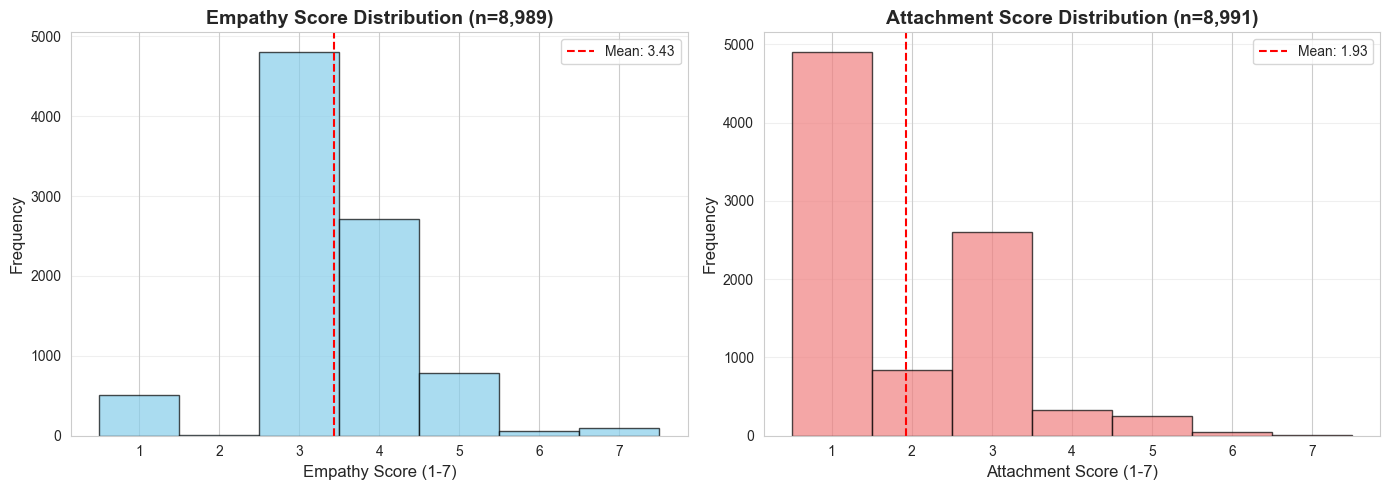


Empathy Score Distribution:
empathy_score
1.0     511
2.0      10
3.0    4809
4.0    2715
5.0     779
6.0      64
7.0     101
Name: count, dtype: int64

Attachment Score Distribution:
attachment_score
1.0    4910
2.0     839
3.0    2608
4.0     329
5.0     251
6.0      47
7.0       7
Name: count, dtype: int64


In [6]:
# Plot score distributions
if 'df_scored' in locals() and len(df_scored) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Empathy scores
    empathy_data = df_scored['empathy_score'].dropna()
    if len(empathy_data) > 0:
        axes[0].hist(empathy_data, bins=np.arange(0.5, 8.5, 1), 
                     color='skyblue', edgecolor='black', alpha=0.7)
        axes[0].set_title(f'Empathy Score Distribution (n={len(empathy_data):,})', 
                         fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Empathy Score (1-7)', fontsize=12)
        axes[0].set_ylabel('Frequency', fontsize=12)
        axes[0].set_xticks(range(1, 8))
        axes[0].axvline(empathy_data.mean(), color='red', linestyle='--', 
                       label=f'Mean: {empathy_data.mean():.2f}')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)
    
    # Attachment scores
    attachment_data = df_scored['attachment_score'].dropna()
    if len(attachment_data) > 0:
        axes[1].hist(attachment_data, bins=np.arange(0.5, 8.5, 1), 
                     color='lightcoral', edgecolor='black', alpha=0.7)
        axes[1].set_title(f'Attachment Score Distribution (n={len(attachment_data):,})', 
                         fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Attachment Score (1-7)', fontsize=12)
        axes[1].set_ylabel('Frequency', fontsize=12)
        axes[1].set_xticks(range(1, 8))
        axes[1].axvline(attachment_data.mean(), color='red', linestyle='--', 
                       label=f'Mean: {attachment_data.mean():.2f}')
        axes[1].legend()
        axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print value counts
    print("\nEmpathy Score Distribution:")
    print(df_scored['empathy_score'].value_counts().sort_index())
    print("\nAttachment Score Distribution:")
    print(df_scored['attachment_score'].value_counts().sort_index())
else:
    print("⚠️  Load the data first!")

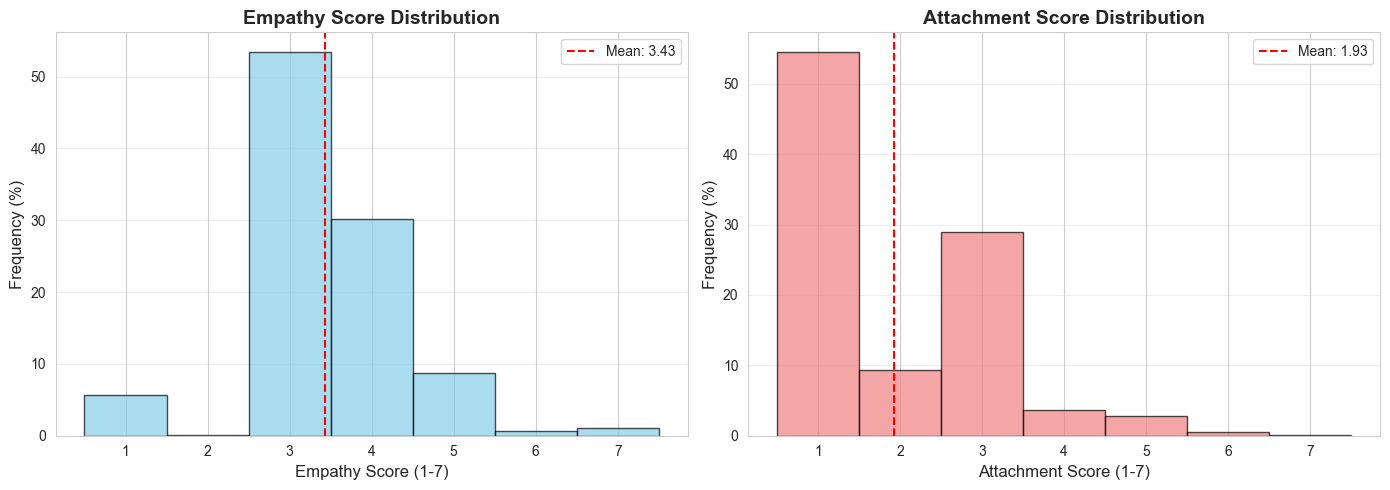


Empathy Score Distribution (%):
empathy_score
1.0     5.68
2.0     0.11
3.0    53.50
4.0    30.20
5.0     8.67
6.0     0.71
7.0     1.12
Name: proportion, dtype: float64

Attachment Score Distribution (%):
attachment_score
1.0    54.61
2.0     9.33
3.0    29.01
4.0     3.66
5.0     2.79
6.0     0.52
7.0     0.08
Name: proportion, dtype: float64


In [9]:
# Plot score distributions
if 'df_scored' in locals() and len(df_scored) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Empathy scores
    empathy_data = df_scored['empathy_score'].dropna()
    if len(empathy_data) > 0:
        axes[0].hist(empathy_data, bins=np.arange(0.5, 8.5, 1), 
                     color='skyblue', edgecolor='black', alpha=0.7,
                     weights=np.ones(len(empathy_data)) / len(empathy_data) * 100)
        axes[0].set_title(f'Empathy Score Distribution', 
                         fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Empathy Score (1-7)', fontsize=12)
        axes[0].set_ylabel('Frequency (%)', fontsize=12)
        axes[0].set_xticks(range(1, 8))
        axes[0].axvline(empathy_data.mean(), color='red', linestyle='--', 
                       label=f'Mean: {empathy_data.mean():.2f}')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)
    
    # Attachment scores
    attachment_data = df_scored['attachment_score'].dropna()
    if len(attachment_data) > 0:
        axes[1].hist(attachment_data, bins=np.arange(0.5, 8.5, 1), 
                     color='lightcoral', edgecolor='black', alpha=0.7,
                     weights=np.ones(len(attachment_data)) / len(attachment_data) * 100)
        axes[1].set_title(f'Attachment Score Distribution', 
                         fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Attachment Score (1-7)', fontsize=12)
        axes[1].set_ylabel('Frequency (%)', fontsize=12)
        axes[1].set_xticks(range(1, 8))
        axes[1].axvline(attachment_data.mean(), color='red', linestyle='--', 
                       label=f'Mean: {attachment_data.mean():.2f}')
        axes[1].legend()
        axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print value counts as percentages
    print("\nEmpathy Score Distribution (%):")
    print((df_scored['empathy_score'].value_counts(normalize=True).sort_index() * 100).round(2))
    print("\nAttachment Score Distribution (%):")
    print((df_scored['attachment_score'].value_counts(normalize=True).sort_index() * 100).round(2))
else:
    print("⚠️  Load the data first!")

In [10]:
# Save the figure in high resolution
plt.savefig('score_distributions.png', dpi=300, bbox_inches='tight', facecolor='white')

<Figure size 1200x600 with 0 Axes>

## 5. Correlation Analysis

Examine the relationship between empathy and attachment scores.

In [ ]:
# Correlation analysis
if 'df_scored' in locals() and len(df_scored) > 0:
    # Calculate correlation
    df_complete = df_scored.dropna(subset=['empathy_score', 'attachment_score'])
    
    if len(df_complete) > 10:
        correlation = df_complete[['empathy_score', 'attachment_score']].corr()
        corr_coef = correlation.loc['empathy_score', 'attachment_score']
        
        print("="*70)
        print("📊 CORRELATION ANALYSIS")
        print("="*70)
        print(f"\nPearson Correlation: r = {corr_coef:.3f}")
        print(f"Sample size: n = {len(df_complete):,}")
        print("\nCorrelation Matrix:")
        print(correlation)
        print("="*70)
        
        # Scatter plot
        plt.figure(figsize=(10, 6))
        
        # Sample if too many points (for performance)
        if len(df_complete) > 10000:
            sample_size = 10000
            df_plot = df_complete.sample(n=sample_size, random_state=42)
            title_suffix = f" (showing {sample_size:,} random samples)"
        else:
            df_plot = df_complete
            title_suffix = ""
        
        plt.scatter(df_plot['empathy_score'], df_plot['attachment_score'], 
                   alpha=0.4, s=30, color='steelblue', edgecolor='none')
        plt.xlabel('Empathy Score (T)', fontsize=12)
        plt.ylabel('Attachment Score (Y)', fontsize=12)
        plt.title(f'Empathy vs Attachment{title_suffix}', fontsize=14, fontweight='bold')
        plt.xticks(range(1, 8))
        plt.yticks(range(1, 8))
        plt.grid(alpha=0.3)
        
        # Add correlation coefficient
        plt.text(0.05, 0.95, f'Pearson r = {corr_coef:.3f}\nn = {len(df_complete):,}', 
                transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️  Not enough complete cases for correlation analysis yet")
else:
    print("⚠️  Load the data first!")

## 6. Scores by Model

Compare empathy and attachment scores across different LLM models.

In [ ]:
# Scores by model
if 'df_scored' in locals() and len(df_scored) > 0:
    print("Empathy Scores by Model:")
    print("="*70)
    empathy_by_model = df_scored.groupby('model')['empathy_score'].agg(['mean', 'std', 'count'])
    empathy_by_model = empathy_by_model.sort_values('mean', ascending=False)
    print(empathy_by_model)
    
    print("\n" + "="*70)
    print("\nAttachment Scores by Model:")
    print("="*70)
    attachment_by_model = df_scored.groupby('model')['attachment_score'].agg(['mean', 'std', 'count'])
    attachment_by_model = attachment_by_model.sort_values('mean', ascending=False)
    print(attachment_by_model)
    
    # Box plots
    if len(df_scored) > 50:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Empathy by model
        df_scored.boxplot(column='empathy_score', by='model', ax=axes[0])
        axes[0].set_title('Empathy Scores by Model', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Model', fontsize=12)
        axes[0].set_ylabel('Empathy Score', fontsize=12)
        axes[0].get_figure().suptitle('')
        
        # Attachment by model
        df_scored.boxplot(column='attachment_score', by='model', ax=axes[1])
        axes[1].set_title('Attachment Scores by Model', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Model', fontsize=12)
        axes[1].set_ylabel('Attachment Score', fontsize=12)
        axes[1].get_figure().suptitle('')
        
        plt.tight_layout()
        plt.show()
else:
    print("⚠️  Load the data first!")

## 7. Summary

Quick summary of current progress and key findings.

In [ ]:
# Generate summary
if 'df_scored' in locals() and len(df_scored) > 0:
    print("="*70)
    print("📊 SCORING SUMMARY")
    print("="*70)
    print(f"\n✓ Conversations scored: {len(df_scored):,} / {TOTAL_CONVERSATIONS:,}")
    print(f"  Progress: {len(df_scored)/TOTAL_CONVERSATIONS*100:.1f}%")
    
    if 'empathy_data' in locals() and len(empathy_data) > 0:
        print(f"\n📈 Empathy Scores (Treatment):")
        print(f"  Mean: {empathy_data.mean():.2f} (SD: {empathy_data.std():.2f})")
        print(f"  Median: {empathy_data.median():.0f}")
        print(f"  Range: {empathy_data.min():.0f} - {empathy_data.max():.0f}")
    
    if 'attachment_data' in locals() and len(attachment_data) > 0:
        print(f"\n📈 Attachment Scores (Outcome):")
        print(f"  Mean: {attachment_data.mean():.2f} (SD: {attachment_data.std():.2f})")
        print(f"  Median: {attachment_data.median():.0f}")
        print(f"  Range: {attachment_data.min():.0f} - {attachment_data.max():.0f}")
    
    if 'corr_coef' in locals():
        print(f"\n🔗 Correlation:")
        print(f"  Empathy ↔ Attachment: r = {corr_coef:.3f}")
    
    print(f"\n🎯 Data Quality:")
    missing_emp_pct = df_scored['empathy_score'].isna().sum() / len(df_scored) * 100
    missing_att_pct = df_scored['attachment_score'].isna().sum() / len(df_scored) * 100
    print(f"  Missing empathy: {missing_emp_pct:.2f}%")
    print(f"  Missing attachment: {missing_att_pct:.2f}%")
    
    remaining = TOTAL_CONVERSATIONS - len(df_scored)
    if remaining > 0:
        print(f"\n⏱️  Estimated time remaining:")
        print(f"  {remaining/(0.8*3600):.1f} hours at 0.8 conv/s")
    else:
        print(f"\n🎉 Scoring complete!")
    
    print("="*70)
else:
    print("⚠️  No data loaded. Run the cells above to load and analyze data.")

---

## 💡 Usage Tips

**How to use this notebook:**

1. **Run all cells** periodically (every few hours) to check progress
2. **Monitor the checkpoint file** as it grows
3. **Watch for data quality issues** early (missing scores, out-of-range values)
4. **Observe preliminary patterns** in distributions and correlations

**When to run:**
- After first checkpoint (1,000 conversations) to validate setup
- Every ~10,000 conversations to check quality
- Periodically during the 50-hour scoring process
- After completion for final analysis

**What to watch for:**
- ✅ Missing scores < 1% (acceptable)
- ✅ Scores in valid range (1-7)
- ✅ Reasonable distributions (not all 1s or 7s)
- ✅ Correlation makes sense (positive but not perfect)

**For full causal analysis**, wait until scoring is complete, then use:
- `03_analysis.ipynb` for propensity score matching and causal inference